# EDA e preparação da base Minerva

Este notebook verifica se a amostra possui qualidade, variação de preço e cobertura de calendário suficientes para sustentar a estimação posterior de uma curva de demanda. A análise usa apenas o período de desenvolvimento, de 01/08/2025 a 31/10/2025.

A EDA gera hipóteses e um catálogo de modelos candidatos. Ela não escolhe a curva final, não define grupos definitivos e não utiliza os resultados do holdout para tomar decisões. A narrativa é autocontida e parte somente da planilha original, do enunciado e das referências bibliográficas listadas ao final.

## 1. Contrato analítico

- **Pergunta estatística futura:** dado um preço candidato e o contexto conhecido do dia, qual volume se espera vender?
- **Alvo:** volume realizado em kg.
- **Preço observado:** receita dividida por volume, interpretado como preço médio realizado no dia.
- **Desenvolvimento:** observações até 31/10/2025.
- **Holdout oficial:** observações posteriores ao corte, apenas separadas e persistidas neste notebook.
- **Regra:** nenhuma distribuição, correlação ou resultado de demanda do holdout será exibido.
- **Unidade de decisão:** kg por dia e por semana, pois a etapa seguinte precisará atender metas semanais.

In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
RAW_DATA_DIR = ROOT / 'data/raw'
INTERIM_DATA_DIR = ROOT / 'data/interim'
PROCESSED_DATA_DIR = ROOT / 'data/processed'
REPORTS_DIR = ROOT / 'reports'
FIGURES_DIR = REPORTS_DIR / 'figures'
INTERIM_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR = REPORTS_DIR / 'tables'
TABLES_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 30)
ORDEM_DIAS = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
CORES_DIAS = dict(zip(ORDEM_DIAS, sns.color_palette('tab10', n_colors=7)))
NOMES_DIAS = dict(enumerate(ORDEM_DIAS))
NOMES_MESES = {8: 'Agosto', 9: 'Setembro', 10: 'Outubro', 11: 'Novembro'}
SEMENTE = 42

## 2. Leitura, validação e isolamento temporal

A planilha original permanece imutável em `data/raw`. As células abaixo validam o esquema, normalizam os tipos e persistem arquivos intermediários com nomes explícitos. Depois da separação, toda a exploração usa somente `desenvolvimento`.

In [2]:
ARQUIVO_FONTE = RAW_DATA_DIR / 'instance_desafio_minerva.xlsx'
historico = pd.read_excel(ARQUIVO_FONTE, sheet_name='base_dados')
restricoes = pd.read_excel(ARQUIVO_FONTE, sheet_name='meta_vol_variacao_preco')

colunas_obrigatorias = [
    'Produto', 'Data', 'Volume Realizado (kg)',
    'Receita Realizada (R$)', 'Custo Realizado (R$)',
]
faltantes = set(colunas_obrigatorias) - set(historico.columns)
if faltantes:
    raise ValueError(f'Colunas obrigatórias ausentes: {sorted(faltantes)}')

historico['Data'] = pd.to_datetime(historico['Data'], errors='raise')
historico = historico.sort_values(['Produto', 'Data']).reset_index(drop=True)
colunas_medidas = ['Volume Realizado (kg)', 'Receita Realizada (R$)', 'Custo Realizado (R$)']
historico[colunas_medidas] = historico[colunas_medidas].apply(pd.to_numeric, errors='raise')
if historico[colunas_obrigatorias].isna().any().any():
    raise ValueError('A base possui valores ausentes nas colunas obrigatórias.')
if historico.duplicated(['Produto', 'Data']).any():
    raise ValueError('A base possui combinações produto-data duplicadas.')
if (historico[colunas_medidas] <= 0).any().any():
    raise ValueError('Volume, receita e custo devem ser positivos para a EDA.')

DATA_CORTE = pd.Timestamp('2025-10-31')
desenvolvimento = historico.loc[historico['Data'] <= DATA_CORTE].copy().reset_index(drop=True)
holdout = historico.loc[historico['Data'] > DATA_CORTE].copy().reset_index(drop=True)

historico.to_csv(INTERIM_DATA_DIR / 'minerva_historico_limpo.csv', index=False)
desenvolvimento.to_csv(INTERIM_DATA_DIR / 'minerva_treino.csv', index=False)
holdout.to_csv(INTERIM_DATA_DIR / 'minerva_holdout.csv', index=False)
restricoes.to_csv(INTERIM_DATA_DIR / 'minerva_restricoes.csv', index=False)

print(f'Histórico validado: {len(historico)} linhas.')
print(
    f'Desenvolvimento isolado: {len(desenvolvimento)} linhas, '
    f'de {desenvolvimento["Data"].min().date()} a {desenvolvimento["Data"].max().date()}.'
)
print(f'Holdout isolado: {len(holdout)} linhas. Seus resultados não são examinados nesta EDA.')

Histórico validado: 86 linhas.
Desenvolvimento isolado: 76 linhas, de 2025-08-01 a 2025-10-31.
Holdout isolado: 10 linhas. Seus resultados não são examinados nesta EDA.


**Resultado da leitura e separação.** A fonte contém 86 registros. O corte temporal reservou 76 observações entre 01/08/2025 e 31/10/2025 para desenvolvimento e isolou 10 observações posteriores no arquivo de holdout. Nenhuma estatística do holdout foi calculada ou exibida; portanto, as hipóteses desta EDA são formuladas somente com o período de desenvolvimento.

### 2.1 Auditoria da fonte e das restrições

O PDF menciona imposto realizado, mas a instância recebida possui apenas produto, data, volume, receita e custo. A tolerância também deve ser lida da planilha, sem fixar no código o percentual citado no texto do enunciado. Essas diferenças são registradas para a modelagem matemática posterior.

In [3]:
colunas_numericas = ['Volume Realizado (kg)', 'Receita Realizada (R$)', 'Custo Realizado (R$)']
auditoria = pd.DataFrame({
    'Indicador': [
        'Linhas históricas', 'Produtos', 'Datas duplicadas por produto',
        'Valores ausentes', 'Valores não positivos nas medidas',
        'Coluna de imposto presente'
    ],
    'Resultado': [
        len(historico), historico['Produto'].nunique(),
        int(historico.duplicated(['Produto', 'Data']).sum()),
        int(historico.isna().sum().sum()),
        int((historico[colunas_numericas] <= 0).sum().sum()),
        'Imposto Realizado (R$)' in historico.columns,
    ],
})
display(auditoria)
display(restricoes.style.format({'Meta (kg)': '{:.1f}', 'Tolerância %': '{:.1%}', 'Variação Máxima Preço Entre Dias Consecutivos (R$)': 'R$ {:.2f}'}))

,Indicador,Resultado
0,Linhas históricas,86
1,Produtos,1
2,Datas duplicadas por produto,0
3,Valores ausentes,0
4,Valores não positivos nas medidas,0
5,Coluna de imposto presente,False


,Semana,Produto,Meta (kg),Tolerância %,Variação Máxima Preço Entre Dias Consecutivos (R$)
0,semana_1,Produto_A,165.0,30.0%,R$ 2.00
1,semana_2,Produto_A,165.0,30.0%,R$ 2.00


**Resultado da auditoria.** Os 86 registros pertencem a um único produto e não há combinações produto-data duplicadas, valores ausentes ou medidas não positivas. Assim, não foi necessário imputar ou remover linhas. A coluna de imposto mencionada no enunciado não existe na planilha e não pode ser reconstruída sem uma hipótese adicional. Para as duas semanas, a instância informa meta de `165 kg`, tolerância de `30%` e variação máxima de `R$ 2,00` entre dias consecutivos; esses valores da planilha, e não percentuais fixados manualmente, devem alimentar a otimização.

## 3. Variáveis canônicas

Preço e custo unitário são reconstruídos a partir dos totais realizados. Receita e margem são descrições ex post; não serão candidatas a explicar a demanda. Calendário e tendência são conhecidos antes da decisão e podem ser avaliados posteriormente.

In [4]:
base = desenvolvimento.sort_values(['Produto', 'Data']).reset_index(drop=True)
treino = pd.DataFrame({
    'produto': base['Produto'],
    'data': base['Data'],
    'volume_kg': base['Volume Realizado (kg)'].astype(float),
    'receita_rs': base['Receita Realizada (R$)'].astype(float),
    'custo_rs': base['Custo Realizado (R$)'].astype(float),
})
treino['preco_kg'] = treino['receita_rs'] / treino['volume_kg']
treino['custo_kg'] = treino['custo_rs'] / treino['volume_kg']
treino['margem_rs_ex_post'] = treino['receita_rs'] - treino['custo_rs']
treino['margem_unitaria_ex_post'] = treino['preco_kg'] - treino['custo_kg']
treino['ln_volume'] = np.log(treino['volume_kg'])
treino['ln_preco'] = np.log(treino['preco_kg'])
treino['numero_dia_semana'] = treino['data'].dt.dayofweek
treino['dia_semana'] = treino['numero_dia_semana'].map(NOMES_DIAS)
treino['fim_semana'] = treino['numero_dia_semana'].ge(5)
treino['mes'] = treino['data'].dt.month
treino['mes_nome'] = treino['mes'].map(NOMES_MESES)
treino['quinzena'] = np.where(treino['data'].dt.day <= 15, '1ª quinzena', '2ª quinzena')
treino['semana_mes'] = ((treino['data'].dt.day - 1) // 7 + 1).astype(int)
treino['indice_tempo'] = treino.groupby('produto', sort=False).cumcount()
treino['inicio_semana'] = treino['data'] - pd.to_timedelta(treino['numero_dia_semana'], unit='D')
ARQUIVO_MODELAGEM = PROCESSED_DATA_DIR / 'minerva_modelagem_treino.csv'
treino.to_csv(ARQUIVO_MODELAGEM, index=False)

dicionario = pd.DataFrame([
    ('volume_kg', 'Volume vendido no dia', 'Alvo', 'kg'),
    ('preco_kg', 'Receita dividida pelo volume', 'Explicativa central', 'R$/kg'),
    ('custo_kg', 'Custo dividido pelo volume', 'Entrada futura da otimização', 'R$/kg'),
    ('ln_volume', 'Logaritmo do volume', 'Resposta candidata', 'log(kg)'),
    ('ln_preco', 'Logaritmo do preço', 'Elasticidade candidata', 'log(R$/kg)'),
    ('dia_semana', 'Dia derivado da data', 'Contexto candidato', 'categoria'),
    ('fim_semana', 'Indicador de sábado ou domingo', 'Contexto parcimonioso', 'booleano'),
    ('mes_nome', 'Mês derivado da data', 'Hipótese sazonal', 'categoria'),
    ('quinzena', 'Metade do mês', 'Hipótese sazonal', 'categoria'),
    ('semana_mes', 'Bloco de sete dias no mês', 'Hipótese sazonal', 'inteiro'),
    ('indice_tempo', 'Ordem cronológica por produto', 'Hipótese de tendência', 'inteiro'),
    ('margem_unitaria_ex_post', 'Preço menos custo realizado', 'Descrição, nunca preditor', 'R$/kg'),
], columns=['Variável', 'Definição', 'Papel', 'Unidade'])
display(dicionario)
display(treino.head())

,Variável,Definição,Papel,Unidade
0,volume_kg,Volume vendido no dia,Alvo,kg
1,preco_kg,Receita dividida pelo volume,Explicativa central,R$/kg
2,custo_kg,Custo dividido pelo volume,Entrada futura da otimização,R$/kg
3,ln_volume,Logaritmo do volume,Resposta candidata,log(kg)
4,ln_preco,Logaritmo do preço,Elasticidade candidata,log(R$/kg)
5,dia_semana,Dia derivado da data,Contexto candidato,categoria
6,fim_semana,Indicador de sábado ou domingo,Contexto parcimonioso,booleano
7,mes_nome,Mês derivado da data,Hipótese sazonal,categoria
8,quinzena,Metade do mês,Hipótese sazonal,categoria
9,semana_mes,Bloco de sete dias no mês,Hipótese sazonal,inteiro


,produto,data,volume_kg,receita_rs,custo_rs,preco_kg,custo_kg,margem_rs_ex_post,margem_unitaria_ex_post,ln_volume,ln_preco,numero_dia_semana,dia_semana,fim_semana,mes,mes_nome,quinzena,semana_mes,indice_tempo,inicio_semana
0,Produto_A,2025-08-01,5.625635,7133.019652,5534.450571,1267.949227,983.791250,1598.569081,284.157976,1.727334,7.145156,4,Sexta,False,8,Agosto,1ª quinzena,1,0,2025-07-28
1,Produto_A,2025-08-04,31.390461,40158.939205,30916.668770,1279.335771,984.906501,9242.270435,294.429271,3.446504,7.154096,0,Segunda,False,8,Agosto,1ª quinzena,1,1,2025-08-04
2,Produto_A,2025-08-05,22.184888,27917.662274,21866.701598,1258.408986,985.657521,6050.960677,272.751465,3.099411,7.137603,1,Terça,False,8,Agosto,1ª quinzena,1,2,2025-08-04
3,Produto_A,2025-08-06,11.030794,13690.691276,10860.556597,1241.133798,984.567075,2830.134679,256.566724,2.400691,7.123781,2,Quarta,False,8,Agosto,1ª quinzena,1,3,2025-08-04
4,Produto_A,2025-08-07,15.160805,18998.292522,14966.405805,1253.118993,987.177524,4031.886717,265.941469,2.718713,7.133391,3,Quinta,False,8,Agosto,1ª quinzena,1,4,2025-08-04


**Resultado da construção.** As variáveis foram calculadas para as 76 observações de desenvolvimento, sem perda de linhas. Como volume, preço e custo são positivos, os logaritmos estão definidos em toda a amostra. O arquivo processado preserva a data, as unidades originais e a distinção entre informações conhecidas antes da decisão e medidas `ex post`; receita e margem permanecem disponíveis para descrição, mas não entram como preditores de demanda.

## 4. Distribuições e suporte inicial

Histogramas, medidas de posição, dispersão e assimetria são usados para reconhecer a escala, a concentração e o domínio efetivamente observado. Essa leitura orienta transformações e alerta para caudas ou valores raros, mas não estabelece causalidade nem basta para classificar uma observação como erro. O logaritmo será mantido como representação candidata porque comprime a cauda do volume e, no modelo log-log, permite interpretar o coeficiente de preço como elasticidade.

,count,mean,std,min,25%,50%,75%,max,assimetria
volume_kg,76.0,21.126,18.940,0.588,7.603,16.700,28.453,100.000,1.665
preco_kg,76.0,1275.023,39.231,1188.864,1245.922,1276.492,1298.936,1365.491,0.062
custo_kg,76.0,981.625,12.955,949.119,973.951,983.672,986.235,1030.343,0.684
margem_unitaria_ex_post,76.0,293.397,38.763,208.877,266.873,296.884,322.289,378.126,-0.285


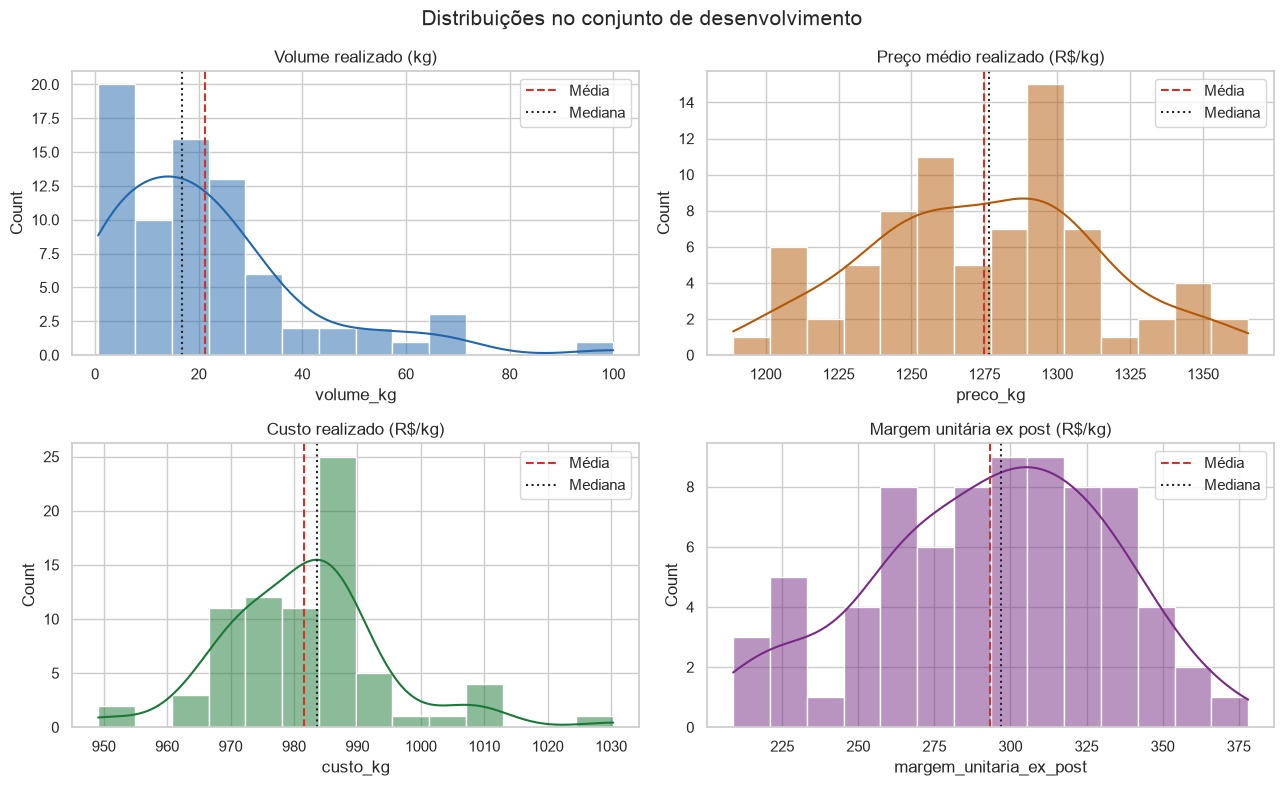

In [5]:
variaveis_resumo = ['volume_kg', 'preco_kg', 'custo_kg', 'margem_unitaria_ex_post']
resumo_descritivo = treino[variaveis_resumo].describe(percentiles=[0.25, 0.5, 0.75]).T
resumo_descritivo['assimetria'] = treino[variaveis_resumo].skew()
display(resumo_descritivo.round(3))

rotulos = {
    'volume_kg': 'Volume realizado (kg)',
    'preco_kg': 'Preço médio realizado (R$/kg)',
    'custo_kg': 'Custo realizado (R$/kg)',
    'margem_unitaria_ex_post': 'Margem unitária ex post (R$/kg)',
}
cores = ['#2166ac', '#b35806', '#1b7837', '#762a83']
fig, eixos = plt.subplots(2, 2, figsize=(13, 8))
for ax, coluna, cor in zip(eixos.flat, variaveis_resumo, cores):
    sns.histplot(treino[coluna], bins=14, kde=True, color=cor, ax=ax)
    ax.axvline(treino[coluna].mean(), color='#d73027', linestyle='--', label='Média')
    ax.axvline(treino[coluna].median(), color='#252525', linestyle=':', label='Mediana')
    ax.set_title(rotulos[coluna])
    ax.legend()
fig.suptitle('Distribuições no conjunto de desenvolvimento', fontsize=15)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '01_distribuicoes.png', dpi=160, bbox_inches='tight')
plt.show()

**Resultado das distribuições.** O volume apresenta cauda à direita: média de `21,13 kg`, mediana de `16,70 kg`, máximo de `100 kg` e assimetria de `1,665`. Isso sustenta avaliar `ln(volume)` como resposta, sem apagar a observação máxima. O preço varia de `R$ 1.188,86/kg` a `R$ 1.365,49/kg`, com média de `R$ 1.275,02/kg` e assimetria próxima de zero (`0,062`), indicando variação empírica para estudar associação preço-volume dentro dessa faixa. O custo é mais concentrado, com média de `R$ 981,63/kg` e desvio-padrão de `R$ 12,96/kg`; a margem unitária `ex post` é descritiva e não será usada para prever volume.

## 5. Evolução cronológica

As séries são apresentadas em ordem cronológica para verificar mudanças de faixa, sequências de dias atípicos e estabilidade do custo antes de qualquer agregação. A coincidência temporal entre movimentos de preço e volume pode sugerir episódios para investigação, mas não identifica por si só uma resposta causal ao preço.

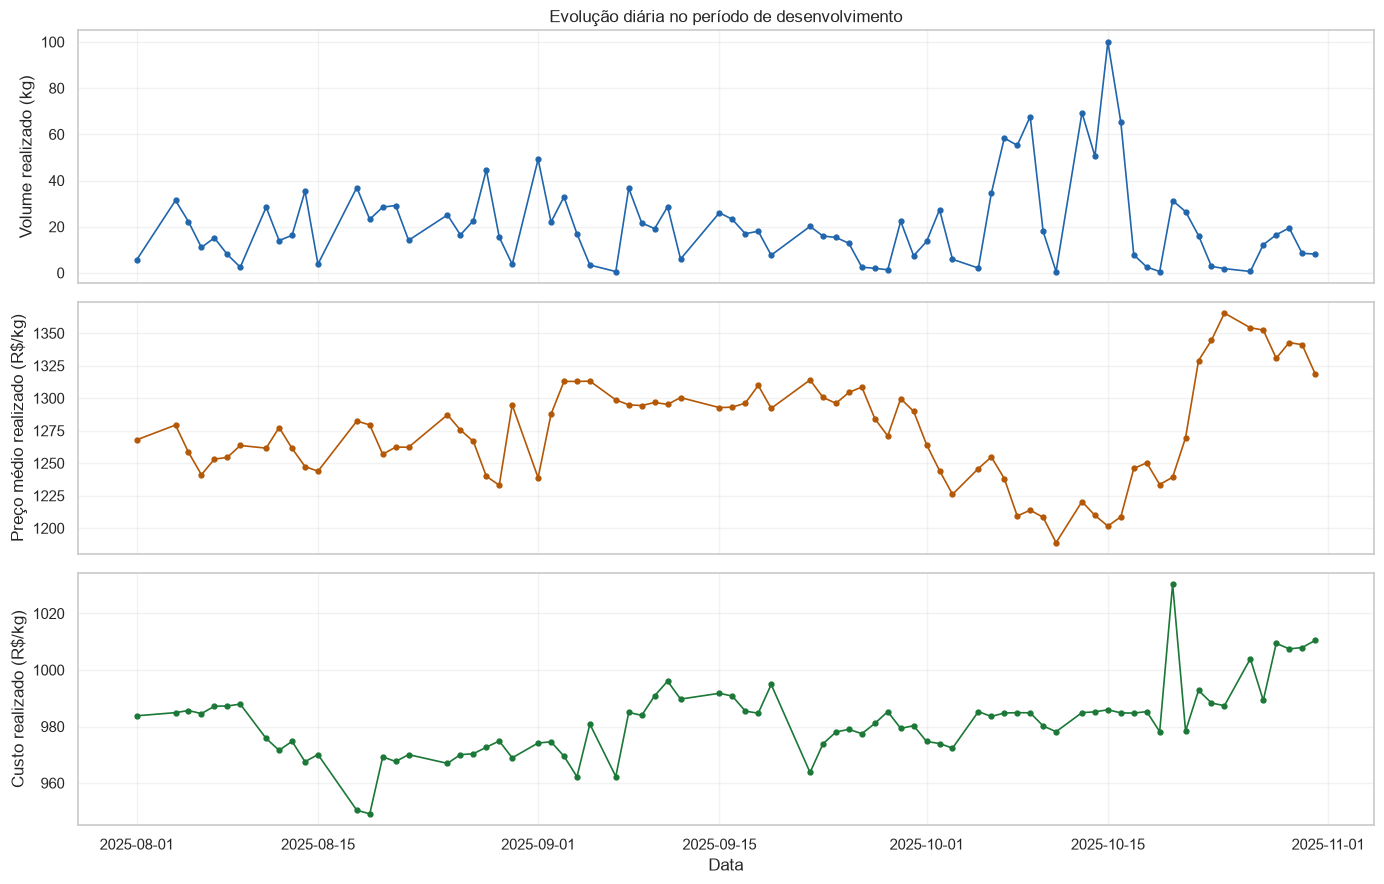

In [6]:
fig, eixos = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
series = [
    ('volume_kg', 'Volume realizado (kg)', '#2166ac'),
    ('preco_kg', 'Preço médio realizado (R$/kg)', '#b35806'),
    ('custo_kg', 'Custo realizado (R$/kg)', '#1b7837'),
]
for ax, (coluna, titulo, cor) in zip(eixos, series):
    ax.plot(treino['data'], treino[coluna], marker='o', markersize=3.5, linewidth=1.2, color=cor)
    ax.set_ylabel(titulo)
    ax.grid(alpha=0.25)
eixos[0].set_title('Evolução diária no período de desenvolvimento')
eixos[-1].set_xlabel('Data')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '01_series_temporais.png', dpi=160, bbox_inches='tight')
plt.show()

**Resultado da evolução temporal.** Agosto e setembro alternam volumes principalmente abaixo de `50 kg`, enquanto o período de 7 a 16 de outubro concentra volumes entre aproximadamente `50 kg` e `100 kg` junto de preços mais baixos. Na parte final de outubro, preços acima de `R$ 1.325/kg` coincidem com volumes baixos. O custo permanece muito mais estável que preço e volume, embora haja um pico próximo de `R$ 1.030/kg` em 20 de outubro e elevação no fim do mês. A sequência sugere associação negativa e possível mudança temporal, mas também mostra que preço e tempo se movem juntos; por isso, `indice_tempo` deve ser apenas uma análise de sensibilidade no Notebook 2.

## 6. Cobertura por dia da semana

Antes de comparar dias da semana, é necessário medir quantas observações e qual faixa de preços sustentam cada grupo. Diferenças visuais com pouco suporte podem ser instáveis; além disso, grupos observados em faixas distintas de preço não são diretamente comparáveis.

,dia_semana,observacoes,volume_medio,volume_mediano,preco_minimo,preco_medio,preco_maximo
0,Segunda,13,32.58,31.31,1220.47,1278.28,1352.42
1,Terça,13,24.45,22.01,1209.83,1277.31,1330.77
2,Quarta,13,28.25,19.14,1201.63,1275.01,1342.80
3,Quinta,13,28.64,27.36,1208.78,1275.24,1344.63
4,Sexta,14,7.72,6.83,1208.37,1274.34,1365.49
5,Sábado,5,2.26,2.46,1188.86,1256.38,1294.79
6,Domingo,5,1.04,0.61,1233.57,1280.66,1354.19


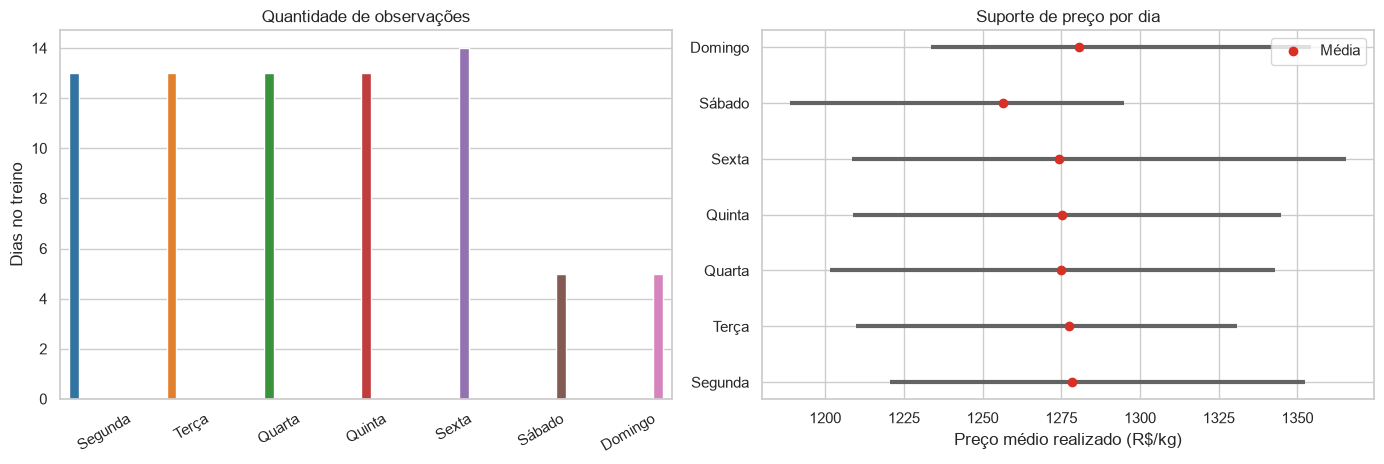

In [7]:
treino['dia_semana'] = pd.Categorical(treino['dia_semana'], categories=ORDEM_DIAS, ordered=True)
suporte_dia = (
    treino.groupby('dia_semana', observed=False)
    .agg(
        observacoes=('volume_kg', 'size'),
        volume_medio=('volume_kg', 'mean'),
        volume_mediano=('volume_kg', 'median'),
        preco_minimo=('preco_kg', 'min'),
        preco_medio=('preco_kg', 'mean'),
        preco_maximo=('preco_kg', 'max'),
    )
    .reset_index()
)
display(suporte_dia.round(2))

fig, eixos = plt.subplots(1, 2, figsize=(14, 4.8))
sns.barplot(data=suporte_dia, x='dia_semana', y='observacoes', hue='dia_semana', palette=CORES_DIAS, legend=False, ax=eixos[0])
eixos[0].set(title='Quantidade de observações', xlabel='', ylabel='Dias no treino')
eixos[0].tick_params(axis='x', rotation=30)
posicoes = np.arange(len(suporte_dia))
eixos[1].hlines(posicoes, suporte_dia['preco_minimo'], suporte_dia['preco_maximo'], color='#636363', linewidth=3)
eixos[1].scatter(suporte_dia['preco_medio'], posicoes, color='#d73027', zorder=3, label='Média')
eixos[1].set_yticks(posicoes, suporte_dia['dia_semana'])
eixos[1].set(title='Suporte de preço por dia', xlabel='Preço médio realizado (R$/kg)', ylabel='')
eixos[1].legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / '01_suporte_dia_semana.png', dpi=160, bbox_inches='tight')
plt.show()

**Resultado do suporte semanal.** Segunda a quinta possuem 13 observações cada e sexta possui 14, enquanto sábado e domingo têm somente 5 observações cada. Nos dias úteis, as médias de volume variam de `7,72 kg` na sexta a `32,58 kg` na segunda; no fim de semana, caem para `2,26 kg` no sábado e `1,04 kg` no domingo. As faixas de preço se sobrepõem entre os dias, mas o suporte de fim de semana é muito pequeno para estimar inclinações próprias com estabilidade. A modelagem deve começar com elasticidade compartilhada e comparar codificações parcimoniosas de nível.

## 7. Sazonalidade: mês, quinzena, semana do mês e dia da semana

Mês, quinzena, semana do mês e dia da semana são examinados como hipóteses de calendário. Para cada recorte, boxplots mostram dispersão e barras mostram médias de **volume** e **preço**. A leitura conjunta é necessária porque uma diferença marginal de volume pode refletir também diferenças de preço ou a presença de poucos valores extremos. Estes gráficos formulam hipóteses; não selecionam variáveis.

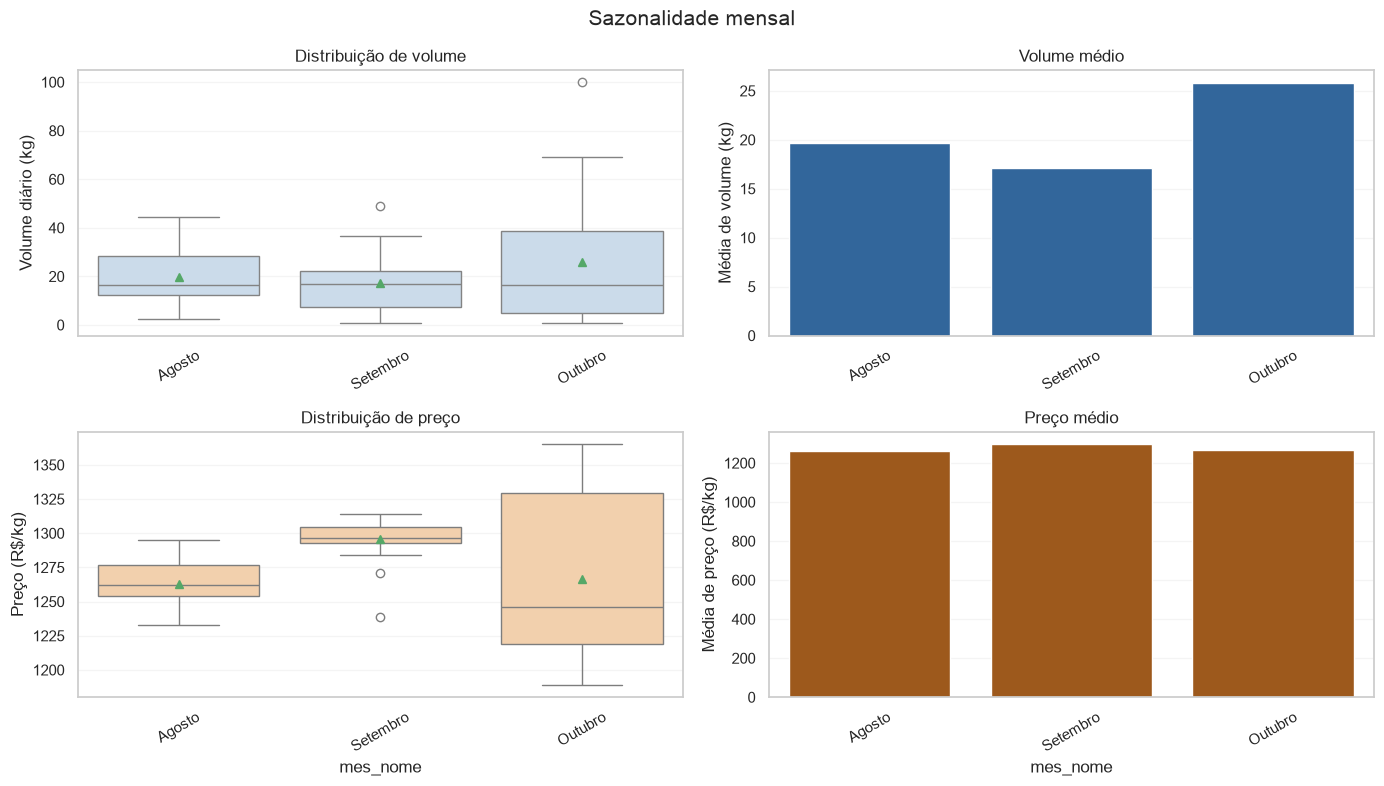

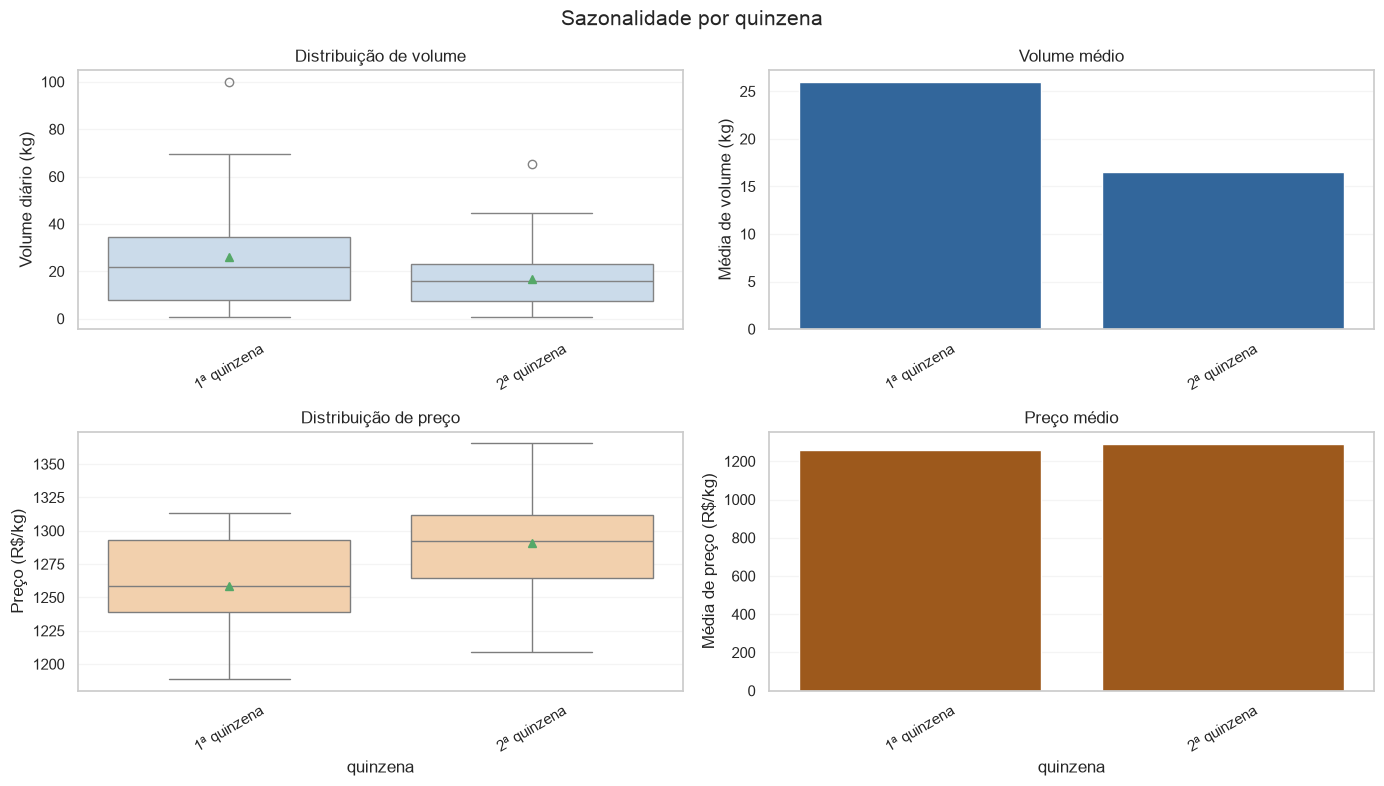

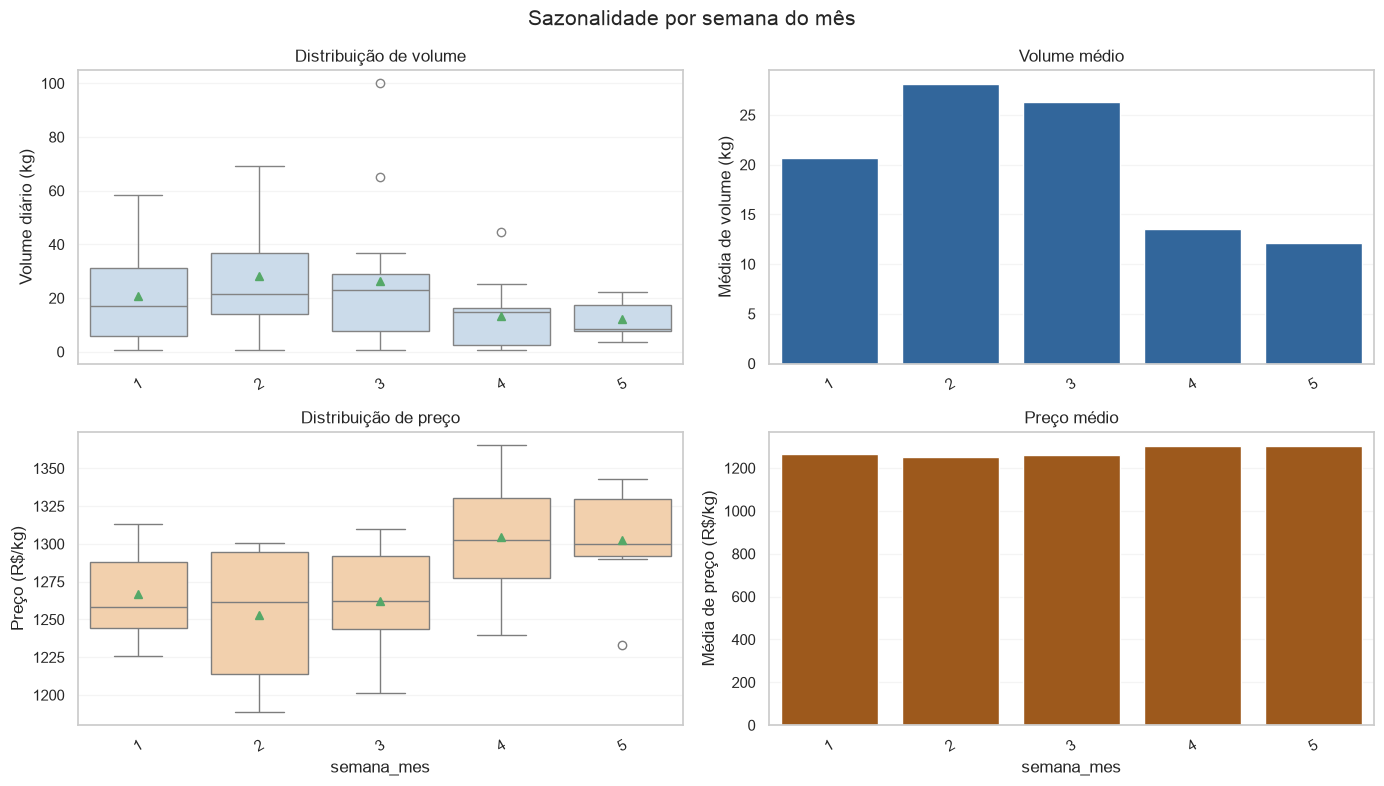

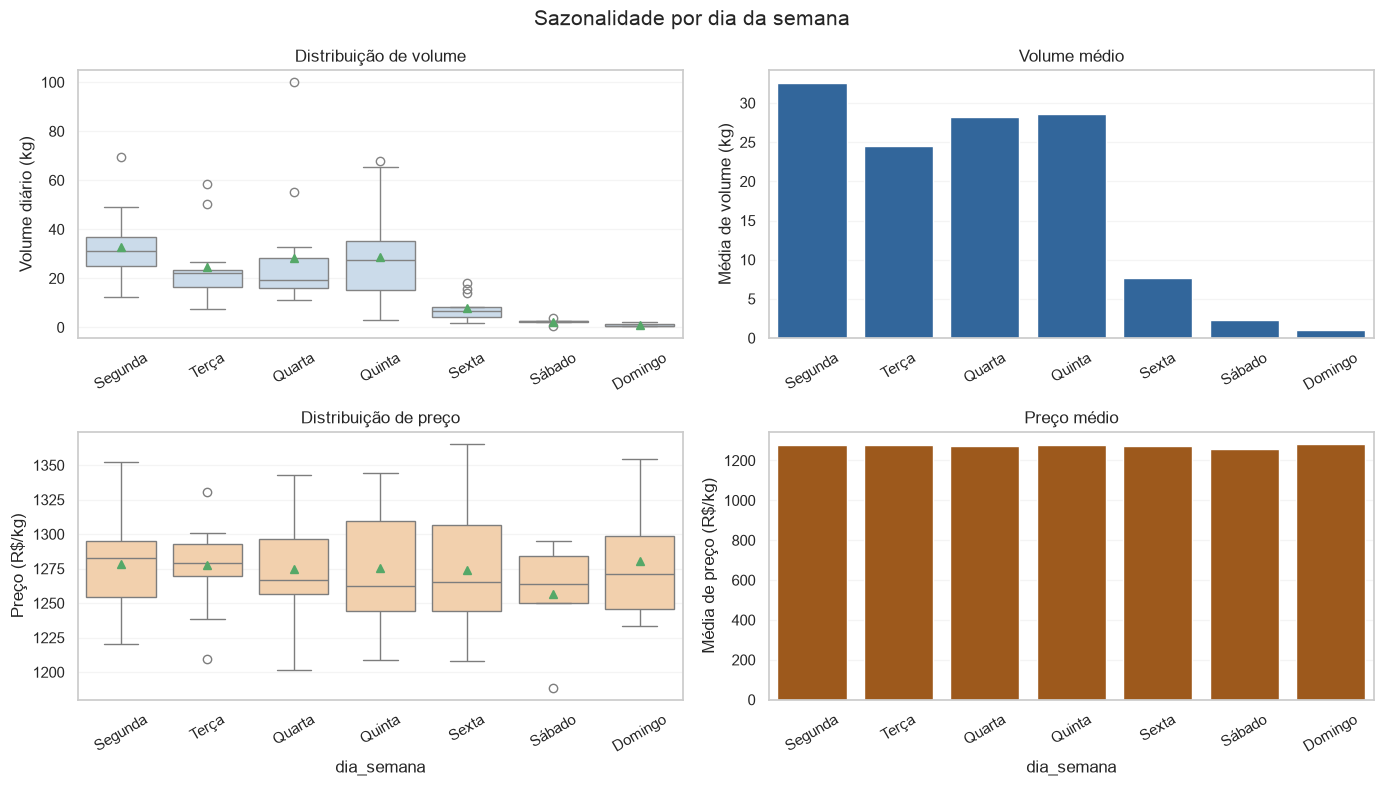

In [8]:
def plotar_perfil_sazonal(dados, coluna, ordem, titulo, arquivo):
    base = dados.copy()
    base[coluna] = pd.Categorical(base[coluna], categories=ordem, ordered=True)
    fig, eixos = plt.subplots(2, 2, figsize=(14, 8))
    sns.boxplot(data=base, x=coluna, y='volume_kg', order=ordem, color='#c6dbef', showmeans=True, ax=eixos[0, 0])
    sns.barplot(data=base, x=coluna, y='volume_kg', order=ordem, color='#2166ac', errorbar=None, ax=eixos[0, 1])
    sns.boxplot(data=base, x=coluna, y='preco_kg', order=ordem, color='#fdd0a2', showmeans=True, ax=eixos[1, 0])
    sns.barplot(data=base, x=coluna, y='preco_kg', order=ordem, color='#b35806', errorbar=None, ax=eixos[1, 1])
    eixos[0, 0].set(title='Distribuição de volume', ylabel='Volume diário (kg)', xlabel='')
    eixos[0, 1].set(title='Volume médio', ylabel='Média de volume (kg)', xlabel='')
    eixos[1, 0].set(title='Distribuição de preço', ylabel='Preço (R$/kg)', xlabel=coluna)
    eixos[1, 1].set(title='Preço médio', ylabel='Média de preço (R$/kg)', xlabel=coluna)
    for ax in eixos.flat:
        ax.tick_params(axis='x', rotation=30)
        ax.grid(axis='y', alpha=0.2)
    fig.suptitle(titulo, fontsize=15)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / arquivo, dpi=160, bbox_inches='tight')
    plt.show()

especificacoes_sazonais = [
    ('mes_nome', ['Agosto', 'Setembro', 'Outubro'], 'Sazonalidade mensal', '01_sazonalidade_mes.png'),
    ('quinzena', ['1ª quinzena', '2ª quinzena'], 'Sazonalidade por quinzena', '01_sazonalidade_quinzena.png'),
    ('semana_mes', [1, 2, 3, 4, 5], 'Sazonalidade por semana do mês', '01_sazonalidade_semana_mes.png'),
    ('dia_semana', ORDEM_DIAS, 'Sazonalidade por dia da semana', '01_sazonalidade_dia_semana.png'),
]
for coluna, ordem, titulo, arquivo in especificacoes_sazonais:
    plotar_perfil_sazonal(treino, coluna, ordem, titulo, arquivo)

**Resultado dos perfis marginais.** Outubro tem o maior volume médio (`25,83 kg`), mas também a maior dispersão e o ponto de `100 kg`; agosto e setembro têm médias de `19,72 kg` e `17,15 kg`. A primeira quinzena combina volume médio maior (`25,94 kg`) com preço médio menor (`R$ 1.258,76/kg`) que a segunda (`16,56 kg` e `R$ 1.290,45/kg`). O mesmo ocorre por semana do mês: semanas 2 e 3 exibem volumes médios de `28,12 kg` e `26,32 kg`, enquanto semanas 4 e 5 têm `13,50 kg` e `12,14 kg` junto de preços médios acima de `R$ 1.300/kg`. Já o dia da semana separa níveis de volume de forma persistente, sobretudo entre segunda a quinta, sexta e fim de semana, sem diferenças equivalentes nas médias de preço. Os padrões de mês, quinzena e semana do mês estão confundidos com preço e serão submetidos à triagem controlada a seguir.

### 7.1 Triagem controlada por preço

Os gráficos anteriores são marginais. Como diagnóstico exploratório adicional, cada hipótese de calendário é adicionada a um baseline `ln(volume) ~ ln(preço)`. O teste F compara os modelos aninhados e pergunta se os coeficientes do calendário, em conjunto, acrescentam ajuste além do preço. O BIC complementa a leitura ao penalizar o ganho de ajuste pelo número de parâmetros; valores menores são preferíveis na comparação relativa. Como a amostra é pequena e temporal, as hipóteses usuais do teste F podem não ser plenamente atendidas. Por isso, p-valor e BIC servem apenas para priorizar candidatos; a seleção final pertence à validação temporal do Notebook 2.

In [9]:
def triar_sazonalidade(dados, coluna, ordem):
    base = dados.copy()
    base[coluna] = pd.Categorical(base[coluna], categories=ordem, ordered=True)
    y = base['ln_volume']
    x_base = sm.add_constant(base[['ln_preco']], has_constant='add')
    dummies = pd.get_dummies(base[coluna], prefix=coluna, drop_first=True, dtype=float)
    x_calendario = sm.add_constant(pd.concat([base[['ln_preco']], dummies], axis=1), has_constant='add')
    modelo_base = sm.OLS(y, x_base).fit()
    modelo_calendario = sm.OLS(y, x_calendario).fit()
    estatistica_f, p_valor, graus_liberdade = modelo_calendario.compare_f_test(modelo_base)
    return {
        'Hipótese': coluna,
        'Grupos': len(ordem),
        'Menor grupo (n)': int(base.groupby(coluna, observed=False).size().min()),
        'F conjunto': estatistica_f,
        'p-valor exploratório': p_valor,
        'BIC baseline': modelo_base.bic,
        'BIC com calendário': modelo_calendario.bic,
        'Delta BIC': modelo_calendario.bic - modelo_base.bic,
    }

triagem_sazonal = pd.DataFrame([
    triar_sazonalidade(treino, coluna, ordem)
    for coluna, ordem, _, _ in especificacoes_sazonais
])
triagem_sazonal.to_csv(TABLES_DIR / '01_resumo_sazonalidade.csv', index=False)
display(triagem_sazonal.round(3))

,Hipótese,Grupos,Menor grupo (n),F conjunto,p-valor exploratório,BIC baseline,BIC com calendário,Delta BIC
0,mes_nome,3,23,0.361,0.698,246.5,254.403,7.903
1,quinzena,2,37,0.311,0.579,246.5,250.508,4.008
2,semana_mes,5,7,0.337,0.852,246.5,262.373,15.873
3,dia_semana,7,5,52.798,0.000,246.5,140.763,-105.737


**Resultado da triagem.** Mês (`p = 0,698`; ΔBIC = `+7,903`), quinzena (`p = 0,579`; ΔBIC = `+4,008`) e semana do mês (`p = 0,852`; ΔBIC = `+15,873`) não melhoraram o baseline nesta triagem: seus BICs aumentaram e os testes conjuntos não indicaram acréscimo de ajuste. Para dia da semana, o teste conjunto produziu `F = 52,798`, `p ≈ 1,11 × 10⁻²³` e ΔBIC = `-105,737`. Assim, dia da semana segue como candidato forte de nível. O resultado não prova causalidade, não define a melhor codificação e não autoriza elasticidades próprias por grupo; essas escolhas serão avaliadas temporalmente no Notebook 2.

## 8. Relação preço-volume dentro do suporte

A dispersão é mostrada nas escalas original e log-log para verificar a direção e a forma da associação dentro do suporte observado. As cores representam contexto de calendário, não grupos definitivos. As correlações são calculadas dentro de cada dia da semana para reduzir a mistura de níveis entre dias: Pearson resume associação linear e Spearman, associação monotônica por postos. Ambas são descritivas, sensíveis ao tamanho dos grupos e não estimam efeito causal.

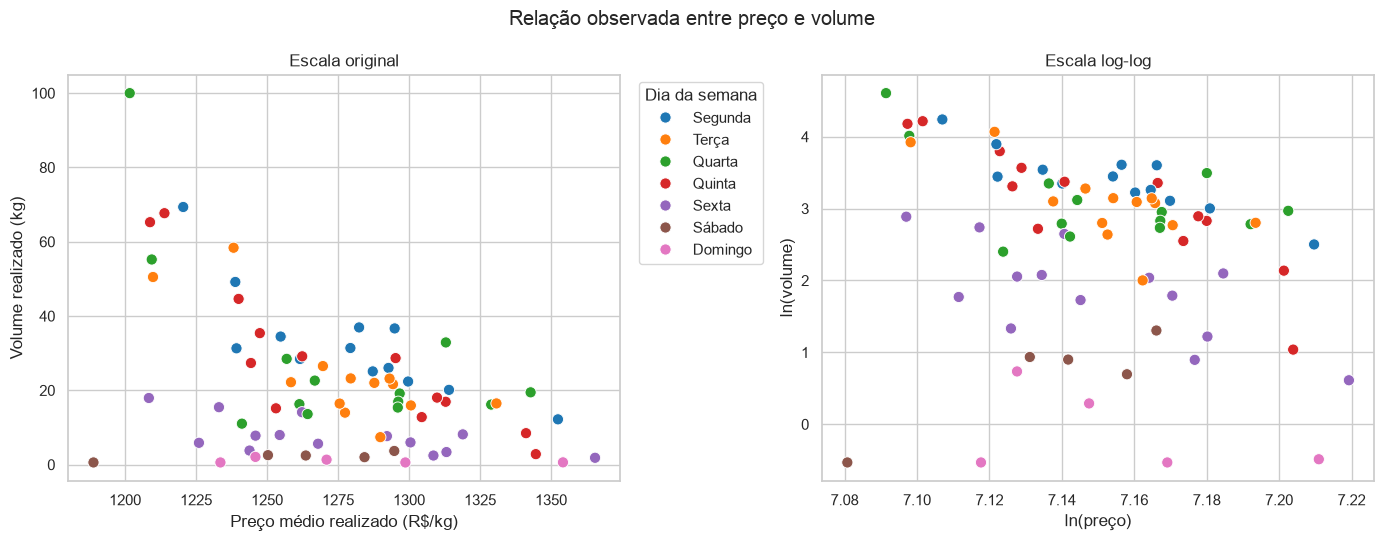

,dia_semana,n,Pearson preço-volume,Spearman preço-volume
0,Segunda,13.0,-0.814,-0.775
1,Terça,13.0,-0.776,-0.588
2,Quarta,13.0,-0.628,-0.198
3,Quinta,13.0,-0.872,-0.868
4,Sexta,14.0,-0.636,-0.530
5,Sábado,5.0,0.861,0.600
6,Domingo,5.0,-0.448,-0.051


In [10]:
fig, eixos = plt.subplots(1, 2, figsize=(14, 5.5))
sns.scatterplot(data=treino, x='preco_kg', y='volume_kg', hue='dia_semana', hue_order=ORDEM_DIAS, palette=CORES_DIAS, s=65, ax=eixos[0])
sns.scatterplot(data=treino, x='ln_preco', y='ln_volume', hue='dia_semana', hue_order=ORDEM_DIAS, palette=CORES_DIAS, s=65, legend=False, ax=eixos[1])
eixos[0].set(title='Escala original', xlabel='Preço médio realizado (R$/kg)', ylabel='Volume realizado (kg)')
eixos[1].set(title='Escala log-log', xlabel='ln(preço)', ylabel='ln(volume)')
eixos[0].legend(title='Dia da semana', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.suptitle('Relação observada entre preço e volume')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '01_preco_volume.png', dpi=160, bbox_inches='tight')
plt.show()

correlacoes_dia = (
    treino.groupby('dia_semana', observed=False)
    .apply(lambda grupo: pd.Series({
        'n': len(grupo),
        'Pearson preço-volume': grupo['preco_kg'].corr(grupo['volume_kg'], method='pearson'),
        'Spearman preço-volume': grupo['preco_kg'].corr(grupo['volume_kg'], method='spearman'),
    }), include_groups=False)
    .reset_index()
)
display(correlacoes_dia.round(3))

**Resultado da associação preço-volume.** De segunda a sexta, as correlações de Pearson são negativas e variam de `-0,628` a `-0,872`; Spearman também é negativa, com maior intensidade na segunda (`-0,775`) e quinta (`-0,868`). Esse padrão é compatível com uma curva decrescente nos dias úteis. No sábado, Pearson é positiva (`0,861`) e, no domingo, Spearman é quase nula (`-0,051`), mas cada grupo possui apenas cinco pontos; esses coeficientes são instáveis e não justificam elasticidades específicas. A dispersão log-log e a estratificação por dia apoiam testar uma inclinação de preço compartilhada com diferenças de nível por calendário.

## 9. Pontos extremos e episódios a investigar

A regra de `1,5 × IQR` é aplicada dentro de cada dia da semana para sinalizar valores marginais distantes sem impor normalidade e sem classificar fins de semana como extremos apenas por seu nível usual mais baixo. Trata-se de uma heurística de investigação, não de um teste para exclusão. A sequência de 10 a 25 de outubro é exibida porque a própria série deste notebook mostra mudanças acentuadas de preço e volume nesse intervalo. Um ponto só poderá ser chamado de discrepante da curva depois que preço e contexto forem controlados no Notebook 2.

,data,dia_semana,volume_kg,preco_kg,extremo_volume,extremo_preco
16,2025-08-22,Sexta,14.11,1262.29,True,False
21,2025-08-29,Sexta,15.46,1233.05,True,False
22,2025-08-30,Sábado,3.68,1294.79,True,False
53,2025-10-07,Terça,58.39,1238.20,True,False
54,2025-10-08,Quarta,55.22,1209.38,True,False
55,2025-10-09,Quinta,67.68,1213.86,True,False
56,2025-10-10,Sexta,17.94,1208.37,True,False
57,2025-10-11,Sábado,0.59,1188.86,True,True
58,2025-10-13,Segunda,69.35,1220.47,True,False
59,2025-10-14,Terça,50.50,1209.83,True,True


,data,dia_semana,volume_kg,preco_kg,custo_kg
56,2025-10-10,Sexta,17.94,1208.37,980.21
57,2025-10-11,Sábado,0.59,1188.86,978.17
58,2025-10-13,Segunda,69.35,1220.47,984.91
59,2025-10-14,Terça,50.50,1209.83,985.19
60,2025-10-15,Quarta,100.00,1201.63,985.92
61,2025-10-16,Quinta,65.26,1208.78,984.83
62,2025-10-17,Sexta,7.80,1245.93,984.74
63,2025-10-18,Sábado,2.55,1250.31,985.27
64,2025-10-19,Domingo,0.59,1233.57,978.17
65,2025-10-20,Segunda,31.31,1239.22,1030.34


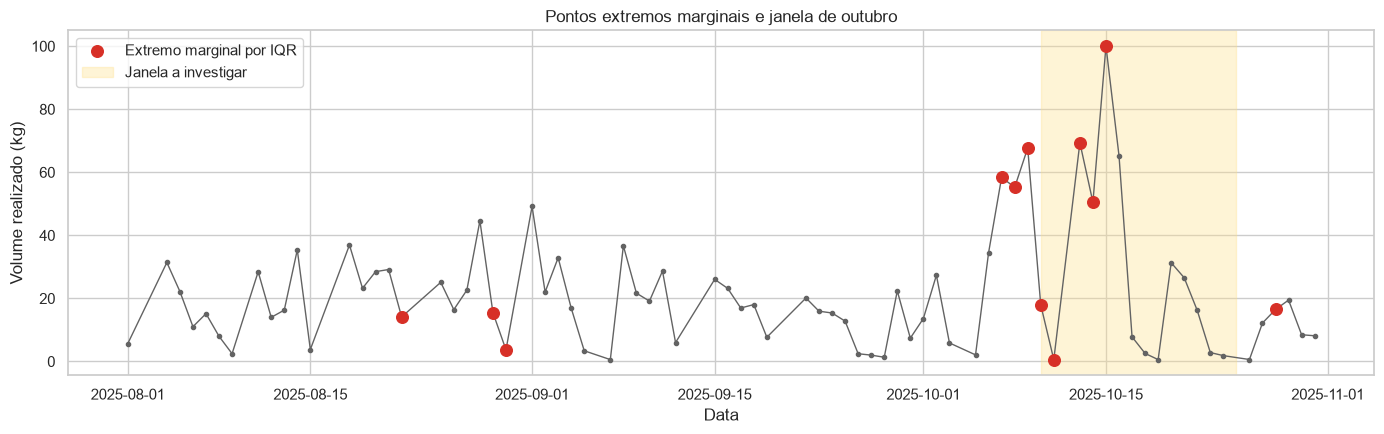

In [11]:
def flag_iqr_por_grupo(dados, valor, grupo='dia_semana'):
    def limites(serie):
        q1, q3 = serie.quantile([0.25, 0.75])
        iqr = q3 - q1
        return q1 - 1.5 * iqr, q3 + 1.5 * iqr

    flags = pd.Series(False, index=dados.index)
    for _, indices in dados.groupby(grupo, observed=False).groups.items():
        inferior, superior = limites(dados.loc[indices, valor])
        flags.loc[indices] = dados.loc[indices, valor].lt(inferior) | dados.loc[indices, valor].gt(superior)
    return flags

diagnostico_marginal = treino.copy()
diagnostico_marginal['extremo_volume'] = flag_iqr_por_grupo(diagnostico_marginal, 'volume_kg')
diagnostico_marginal['extremo_preco'] = flag_iqr_por_grupo(diagnostico_marginal, 'preco_kg')
diagnostico_marginal['extremo_marginal'] = diagnostico_marginal[['extremo_volume', 'extremo_preco']].any(axis=1)
colunas_diagnostico = ['data', 'dia_semana', 'volume_kg', 'preco_kg', 'extremo_volume', 'extremo_preco']
tabela_extremos = diagnostico_marginal.loc[
    diagnostico_marginal['extremo_marginal'], colunas_diagnostico
].copy()
tabela_extremos[['volume_kg', 'preco_kg']] = tabela_extremos[[
    'volume_kg', 'preco_kg'
]].round(2)
display(tabela_extremos)

janela_outubro = diagnostico_marginal.loc[
    diagnostico_marginal['data'].between('2025-10-10', '2025-10-25'),
    ['data', 'dia_semana', 'volume_kg', 'preco_kg', 'custo_kg'],
]
display(janela_outubro.round({'volume_kg': 2, 'preco_kg': 2, 'custo_kg': 2}))

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(diagnostico_marginal['data'], diagnostico_marginal['volume_kg'], color='#636363', linewidth=1, marker='o', markersize=3)
destaques = diagnostico_marginal[diagnostico_marginal['extremo_marginal']]
ax.scatter(destaques['data'], destaques['volume_kg'], color='#d73027', s=70, label='Extremo marginal por IQR', zorder=3)
ax.axvspan(pd.Timestamp('2025-10-10'), pd.Timestamp('2025-10-25'), color='#fee08b', alpha=0.35, label='Janela a investigar')
ax.set(title='Pontos extremos marginais e janela de outubro', xlabel='Data', ylabel='Volume realizado (kg)')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / '01_pontos_extremos_marginais.png', dpi=160, bbox_inches='tight')
plt.show()

**Resultado da sinalização.** A regra marcou 12 datas distintas: 11 por volume, 3 por preço e 2 simultaneamente pelos dois critérios. Oito sinalizações ficam entre 7 e 15 de outubro, quando preços baixos coexistem com volumes elevados em dias úteis; depois, entre 22 e 24 de outubro, preços muito mais altos coexistem com volumes baixos. Como essa concentração forma um episódio temporal coerente e o custo também muda em torno de 20 de outubro, as observações serão mantidas. No Notebook 2, resíduos, influência e estabilidade temporal devem distinguir resposta ao preço, mudança de regime e possível observação influente.

## 10. Hipóteses e modelos que seguem para validação

O encerramento da EDA transforma os achados descritivos em um contrato verificável para o Notebook 2. O catálogo mantém um baseline, alternativas parcimoniosas de calendário e formas funcionais concorrentes. Nenhuma variável ou especificação é declarada vencedora aqui.

In [12]:
catalogo_variaveis = pd.DataFrame([
    ('ln_preco', 'Obrigatória', 'Relação de potência e interpretação direta da elasticidade', 'Preço médio pode ter erro de mensuração'),
    ('fim_semana', 'Candidata', 'Representação de calendário com um parâmetro', 'Somente dez observações de FDS'),
    ('dia_semana', 'Candidata', 'Diferenças de nível visíveis e sinal na triagem', 'Seis parâmetros adicionais'),
    ('grupo_calendario', 'Candidata a definir no treino', 'Alternativa intermediária entre FDS e sete dias', 'Agrupamento precisa ser congelado antes do holdout'),
    ('indice_tempo', 'Sensibilidade', 'Possível mudança de nível ao longo dos meses', 'Pode absorver variação não causal'),
    ('mes/quinzena/semana_mes', 'Documentadas', 'Hipóteses sazonais avaliadas', 'Poucos ciclos mensais disponíveis'),
    ('custo_kg', 'Fora da demanda por padrão', 'Entrada da margem na otimização', 'Não representa necessariamente preferência do cliente'),
    ('receita/margem', 'Proibidas como preditores', 'São consequências de preço e volume', 'Vazamento e relação circular'),
], columns=['Variável', 'Status após EDA', 'Justificativa', 'Risco'])

catalogo_modelos = pd.DataFrame([
    ('P0', 'ln(volume) ~ ln(preço)', 'Baseline de potência sem calendário'),
    ('P1', 'ln(volume) ~ ln(preço) + fim_semana', 'Calendário mínimo'),
    ('P2', 'ln(volume) ~ ln(preço) + C(dia_semana)', 'Níveis diários completos'),
    ('P3', 'ln(volume) ~ ln(preço) + grupo_calendario', 'Partição parcimoniosa definida no treino'),
    ('P4', 'campeão de calendário + indice_tempo', 'Sensibilidade temporal'),
    ('E1', 'ln(volume) ~ preço + calendário campeão', 'Forma exponencial challenger'),
    ('L1', 'volume ~ preço + calendário campeão', 'Diagnóstico linear; rejeitar se gerar volume negativo'),
], columns=['Código', 'Especificação', 'Papel'])

catalogo_variaveis.to_csv(TABLES_DIR / '01_catalogo_variaveis.csv', index=False)
catalogo_modelos.to_csv(TABLES_DIR / '01_catalogo_modelos.csv', index=False)
display(catalogo_variaveis)
display(catalogo_modelos)

,Variável,Status após EDA,Justificativa,Risco
0,ln_preco,Obrigatória,Relação de potência e interpretação direta da ...,Preço médio pode ter erro de mensuração
1,fim_semana,Candidata,Representação de calendário com um parâmetro,Somente dez observações de FDS
2,dia_semana,Candidata,Diferenças de nível visíveis e sinal na triagem,Seis parâmetros adicionais
3,grupo_calendario,Candidata a definir no treino,Alternativa intermediária entre FDS e sete dias,Agrupamento precisa ser congelado antes do hol...
4,indice_tempo,Sensibilidade,Possível mudança de nível ao longo dos meses,Pode absorver variação não causal
5,mes/quinzena/semana_mes,Documentadas,Hipóteses sazonais avaliadas,Poucos ciclos mensais disponíveis
6,custo_kg,Fora da demanda por padrão,Entrada da margem na otimização,Não representa necessariamente preferência do ...
7,receita/margem,Proibidas como preditores,São consequências de preço e volume,Vazamento e relação circular


,Código,Especificação,Papel
0,P0,ln(volume) ~ ln(preço),Baseline de potência sem calendário
1,P1,ln(volume) ~ ln(preço) + fim_semana,Calendário mínimo
2,P2,ln(volume) ~ ln(preço) + C(dia_semana),Níveis diários completos
3,P3,ln(volume) ~ ln(preço) + grupo_calendario,Partição parcimoniosa definida no treino
4,P4,campeão de calendário + indice_tempo,Sensibilidade temporal
5,E1,ln(volume) ~ preço + calendário campeão,Forma exponencial challenger
6,L1,volume ~ preço + calendário campeão,Diagnóstico linear; rejeitar se gerar volume n...


**Resultado do catálogo.** `ln_preco` permanece obrigatório nas curvas de potência; `fim_semana`, `dia_semana` e uma eventual partição parcimoniosa seguem como alternativas de nível; `indice_tempo` fica restrito à sensibilidade. Custo pertence à função de margem da otimização, enquanto receita e margem realizadas são excluídas da demanda para evitar relação circular. O Notebook 2 recebe sete especificações (`P0`–`P4`, `E1` e `L1`) para comparação temporal, sem campeão antecipado pela EDA.

## 11. Conclusões da etapa exploratória

1. A base possui volume e preço positivos e variação de preço suficiente para testar curvas de resposta dentro do intervalo observado.
2. Dia da semana é uma hipótese de nível importante e deve participar da validação temporal; a EDA não define ainda a melhor codificação.
3. Mês, quinzena e semana do mês foram preservados e documentados, mas possuem poucos ciclos e não devem entrar automaticamente.
4. FDS tem suporte reduzido, portanto não justifica elasticidade própria como especificação inicial.
5. Pontos extremos e a janela de outubro permanecem na base; sua influência será diagnosticada condicionalmente à curva no Notebook 2.
6. A ausência de estoque, promoções, concorrência, clima, imposto e preço de lista limita a interpretação causal e operacional.
7. O próximo notebook deve selecionar entre os candidatos exclusivamente por validação temporal no desenvolvimento e só então executar o holdout.

## 12. Validação de integridade e artefatos

As verificações finais confirmam que a base processada conserva todas as observações de desenvolvimento, respeita o corte temporal e contém medidas positivas e completas. Elas também registram os caminhos dos artefatos para reprodução. Nenhum conteúdo do holdout é analisado nessa validação.

In [13]:
assert len(treino) == len(desenvolvimento)
assert treino['data'].max() <= pd.Timestamp('2025-10-31')
assert len(holdout) > 0
assert not treino[['volume_kg', 'preco_kg', 'custo_kg']].isna().any().any()
assert (treino[['volume_kg', 'preco_kg', 'custo_kg']] > 0).all().all()

print('EDA concluída.')
print(f'Base de modelagem: {ARQUIVO_MODELAGEM}')
print(f'Figuras: {FIGURES_DIR}')
print(f'Tabelas de apoio: {TABLES_DIR}')
print('Holdout preservado sem análise de seus resultados.')

EDA concluída.
Base de modelagem: /Users/ngodeny/Documents/mestrado/202602-resolucao_problemas/data/processed/minerva_modelagem_treino.csv
Figuras: /Users/ngodeny/Documents/mestrado/202602-resolucao_problemas/reports/figures
Tabelas de apoio: /Users/ngodeny/Documents/mestrado/202602-resolucao_problemas/reports/tables
Holdout preservado sem análise de seus resultados.


**Resultado da validação.** Todas as verificações foram satisfeitas: as 76 linhas de desenvolvimento chegaram à base processada, a data máxima é 31/10/2025 e volume, preço e custo não possuem valores ausentes ou não positivos. A base, as figuras e as tabelas foram gravadas nos diretórios informados, enquanto o holdout permaneceu apenas isolado.

## 13. Referências

- MINERVA FOODS; UNIFESP; ITA. *Desafio de Otimização de Preços*. Documento do projeto disponível em `docs/Minerva_Unifesp_ITA.pdf`.
- PHILLIPS, Robert L. *Pricing and Revenue Optimization*. 2. ed. Documento disponível em `docs/referencias/dokumen.pub_pricing-and-revenue-optimization-second-edition-9781503614260.pdf`.
- MULLAPUDI, Pavan Nithin. *Pricing Optimization across Domains*. Documento disponível em `docs/referencias/IJERET-V6I3P103.pdf`.